# Customer Churn Prediction Dashboard

Goal: build a classification pipeline to predict customer churn, compare two models, choose a relevant decision threshold, and prepare the final model for the Streamlit application.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

## 1. Data loading

We load the dataset and display a first preview.

In [2]:
df = pd.read_csv("../data/raw/telco-customer-churn.csv")

print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Quick inspection

We check the overall structure of the dataset before cleaning.

In [3]:
print("Dataset shape :", df.shape)
print()

print("Columns :")
print(df.columns.tolist())
print()

print("General information :")
df.info()
print()

print("Missing values :")
print(df.isnull().sum())
print()

print("Target distribution (Churn) :")
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True))
print()

print("Numerical statistics :")
display(df.describe())

print("Categorical statistics :")
display(df.describe(include="object"))

Dataset shape : (7043, 21)

Columns :
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

General information :
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Categorical statistics :


C:\Users\louis\AppData\Local\Temp\ipykernel_29484\1139601196.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Checking `TotalCharges`

This column is often badly typed in this dataset. We check whether it contains hidden blank values.

In [4]:
print("Number of exact empty strings :", (df["TotalCharges"] == "").sum())
print("Number of strings with a space :", (df["TotalCharges"] == " ").sum())

print("\nRows where TotalCharges seems empty :")
display(df[df["TotalCharges"].str.strip() == ""])

Number of exact empty strings : 0
Number of strings with a space : 11

Rows where TotalCharges seems empty :


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## 4. Cleaning

We convert `TotalCharges` to numeric format, remove invalid rows, and drop the customer identifier.

In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges type :", df["TotalCharges"].dtype)
print("Number of missing values :", df["TotalCharges"].isnull().sum())

display(df[df["TotalCharges"].isnull()])

TotalCharges type : float64
Number of missing values : 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
df = df.dropna(subset=["TotalCharges"]).copy()
df = df.drop(columns=["customerID"])

print("New dataset shape :", df.shape)
print("Missing values in TotalCharges :", df["TotalCharges"].isnull().sum())
print("Final type of TotalCharges :", df["TotalCharges"].dtype)
print()

df.info()
print()

print("Unique values in SeniorCitizen :", df["SeniorCitizen"].unique())

New dataset shape : (7032, 20)
Missing values in TotalCharges : 0
Final type of TotalCharges : float64

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  P

## 5. Defining target and features

We separate the target variable `Churn` from the input variables and identify numerical and categorical features.

In [7]:
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn"])

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

print("X shape :", X.shape)
print("y shape :", y.shape)
print()

print("Numerical features :", numeric_features)
print()
print("Categorical features :", categorical_features)
print()

print("Target distribution :")
print(y.value_counts())
print()
print("Target proportions :")
print(y.value_counts(normalize=True))

X shape : (7032, 19)
y shape : (7032,)

Numerical features : ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target distribution :
Churn
0    5163
1    1869
Name: count, dtype: int64

Target proportions :
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


## 6. Train / test split

We split the data to evaluate the models on unseen customers.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)
print()

print("Overall distribution :")
print(y.value_counts(normalize=True))
print()

print("y_train distribution :")
print(y_train.value_counts(normalize=True))
print()

print("y_test distribution :")
print(y_test.value_counts(normalize=True))

X_train shape : (5625, 19)
X_test shape  : (1407, 19)
y_train shape : (5625,)
y_test shape  : (1407,)

Overall distribution :
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

y_train distribution :
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

y_test distribution :
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


## 7. Preprocessing

We create a dedicated pipeline for numerical features and another one for categorical features.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 8. Baseline model: Logistic Regression

We train a simple first model to build a solid baseline.

In [10]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression pipeline trained successfully.")

Logistic Regression pipeline trained successfully.


In [11]:
accuracy = accuracy_score(y_test, y_pred_logreg)
precision = precision_score(y_test, y_pred_logreg)
recall = recall_score(y_test, y_pred_logreg)
f1 = f1_score(y_test, y_pred_logreg)
roc_auc = roc_auc_score(y_test, y_proba_logreg)

print("=== Logistic Regression - Metrics ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print()

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_logreg))
print()

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_logreg))

=== Logistic Regression - Metrics ===
Accuracy  : 0.8045
Precision : 0.6495
Recall    : 0.5749
F1-score  : 0.6099
ROC-AUC   : 0.8359

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


=== Confusion Matrix ===
[[917 116]
 [159 215]]


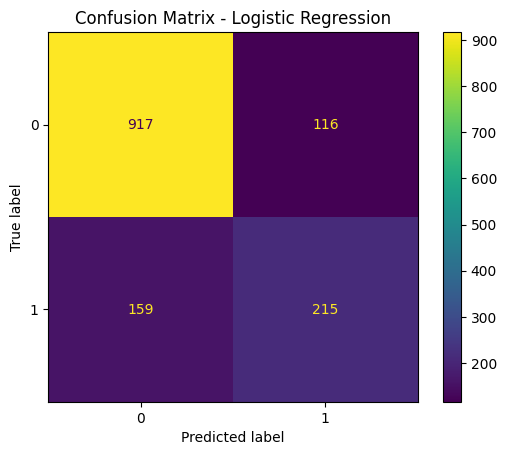

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 9. Second model: Random Forest

We test a more flexible model to see whether it improves the baseline.

In [13]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [14]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=== Random Forest - Metrics ===")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")
print()

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_rf))
print()

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest - Metrics ===
Accuracy  : 0.7925
Precision : 0.6385
Recall    : 0.5053
F1-score  : 0.5642
ROC-AUC   : 0.8258

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


=== Confusion Matrix ===
[[926 107]
 [185 189]]


## 10. Model comparison

We compare both models to select the best candidate.

In [15]:
comparison_df = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "accuracy": [accuracy, accuracy_rf],
    "precision": [precision, precision_rf],
    "recall": [recall, recall_rf],
    "f1_score": [f1, f1_rf],
    "roc_auc": [roc_auc, roc_auc_rf]
})

display(comparison_df)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.792466,0.638514,0.505348,0.564179,0.825763


## 11. Decision threshold analysis

We adjust the Logistic Regression threshold to better manage the precision / recall trade-off.

In [16]:
thresholds = np.arange(0.30, 0.71, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_logreg >= threshold).astype(int)
    
    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1_score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(results)
display(threshold_df)

,threshold,precision,recall,f1_score
0,0.30,0.511712,0.759358,0.611410
1,0.35,0.544534,0.719251,0.619816
2,0.40,0.579186,0.684492,0.627451
3,0.45,0.603581,0.631016,0.616993
4,0.50,0.649547,0.574866,0.609929
5,0.55,0.667897,0.483957,0.561240
6,0.60,0.680751,0.387701,0.494037
7,0.65,0.694805,0.286096,0.405303
8,0.70,0.759036,0.168449,0.275711


In [17]:
best_threshold = 0.40
y_pred_best = (y_proba_logreg >= best_threshold).astype(int)

print("=== Logistic Regression with threshold 0.40 ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

=== Logistic Regression with threshold 0.40 ===
Accuracy  : 0.7839
Precision : 0.5792
Recall    : 0.6845
F1-score  : 0.6275

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407

[[847 186]
 [118 256]]


## 12. Final model interpretation

We extract the Logistic Regression coefficients to identify the most influential factors.

In [18]:
fitted_preprocessor = logreg_pipeline.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = logreg_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

display(coef_df.head())

,feature,coefficient,abs_coefficient
0,num__tenure,-1.350384,1.350384
1,num__MonthlyCharges,-0.530297,0.530297
2,num__TotalCharges,0.642862,0.642862
3,cat__gender_Female,-0.129399,0.129399
4,cat__gender_Male,-0.153549,0.153549


In [19]:
print("Top 10 features associated with higher churn risk:")
display(coef_df.sort_values("coefficient", ascending=False).head(10))

print("Top 10 features associated with lower churn risk:")
display(coef_df.sort_values("coefficient", ascending=True).head(10))

Top 10 features associated with higher churn risk:


,feature,coefficient,abs_coefficient
2,num__TotalCharges,0.642862,0.642862
37,cat__Contract_Month-to-month,0.624313,0.624313
17,cat__InternetService_Fiber optic,0.591880,0.591880
33,cat__StreamingTV_Yes,0.197986,0.197986
44,cat__PaymentMethod_Electronic check,0.188409,0.188409
36,cat__StreamingMovies_Yes,0.183854,0.183854
19,cat__OnlineSecurity_No,0.173613,0.173613
28,cat__TechSupport_No,0.150621,0.150621
15,cat__MultipleLines_Yes,0.093474,0.093474
22,cat__OnlineBackup_No,0.052494,0.052494


Top 10 features associated with lower churn risk:


,feature,coefficient,abs_coefficient
0,num__tenure,-1.350384,1.350384
39,cat__Contract_Two year,-0.772380,0.772380
16,cat__InternetService_DSL,-0.602034,0.602034
1,num__MonthlyCharges,-0.530297,0.530297
40,cat__PaperlessBilling_No,-0.286453,0.286453
13,cat__MultipleLines_No,-0.284063,0.284063
20,cat__OnlineSecurity_No internet service,-0.272794,0.272794
23,cat__OnlineBackup_No internet service,-0.272794,0.272794
26,cat__DeviceProtection_No internet service,-0.272794,0.272794
35,cat__StreamingMovies_No internet service,-0.272794,0.272794


## 13. Readable feature names

We clean feature names to make the results easier to present in the notebook and README.

In [20]:
coef_clean = coef_df.copy()

def clean_feature_name(feature_name):
    if feature_name.startswith("num__"):
        name = feature_name.replace("num__", "")
        return name

    if feature_name.startswith("cat__"):
        name = feature_name.replace("cat__", "")
        if "_" in name:
            parts = name.split("_", 1)
            return f"{parts[0]} = {parts[1]}"
        return name

    return feature_name

coef_clean["feature_clean"] = coef_clean["feature"].apply(clean_feature_name)
coef_clean = coef_clean[["feature_clean", "coefficient", "abs_coefficient"]]

display(coef_clean.head())

,feature_clean,coefficient,abs_coefficient
0,tenure,-1.350384,1.350384
1,MonthlyCharges,-0.530297,0.530297
2,TotalCharges,0.642862,0.642862
3,gender = Female,-0.129399,0.129399
4,gender = Male,-0.153549,0.153549


In [21]:
top_positive_clean = coef_clean.sort_values("coefficient", ascending=False).head(10)
top_negative_clean = coef_clean.sort_values("coefficient", ascending=True).head(10)

print("Top 10 factors associated with higher churn risk:")
display(top_positive_clean)

print("Top 10 factors associated with lower churn risk:")
display(top_negative_clean)

Top 10 factors associated with higher churn risk:


,feature_clean,coefficient,abs_coefficient
2,TotalCharges,0.642862,0.642862
37,Contract = Month-to-month,0.624313,0.624313
17,InternetService = Fiber optic,0.591880,0.591880
33,StreamingTV = Yes,0.197986,0.197986
44,PaymentMethod = Electronic check,0.188409,0.188409
36,StreamingMovies = Yes,0.183854,0.183854
19,OnlineSecurity = No,0.173613,0.173613
28,TechSupport = No,0.150621,0.150621
15,MultipleLines = Yes,0.093474,0.093474
22,OnlineBackup = No,0.052494,0.052494


Top 10 factors associated with lower churn risk:


,feature_clean,coefficient,abs_coefficient
0,tenure,-1.350384,1.350384
39,Contract = Two year,-0.772380,0.772380
16,InternetService = DSL,-0.602034,0.602034
1,MonthlyCharges,-0.530297,0.530297
40,PaperlessBilling = No,-0.286453,0.286453
13,MultipleLines = No,-0.284063,0.284063
20,OnlineSecurity = No internet service,-0.272794,0.272794
23,OnlineBackup = No internet service,-0.272794,0.272794
26,DeviceProtection = No internet service,-0.272794,0.272794
35,StreamingMovies = No internet service,-0.272794,0.272794


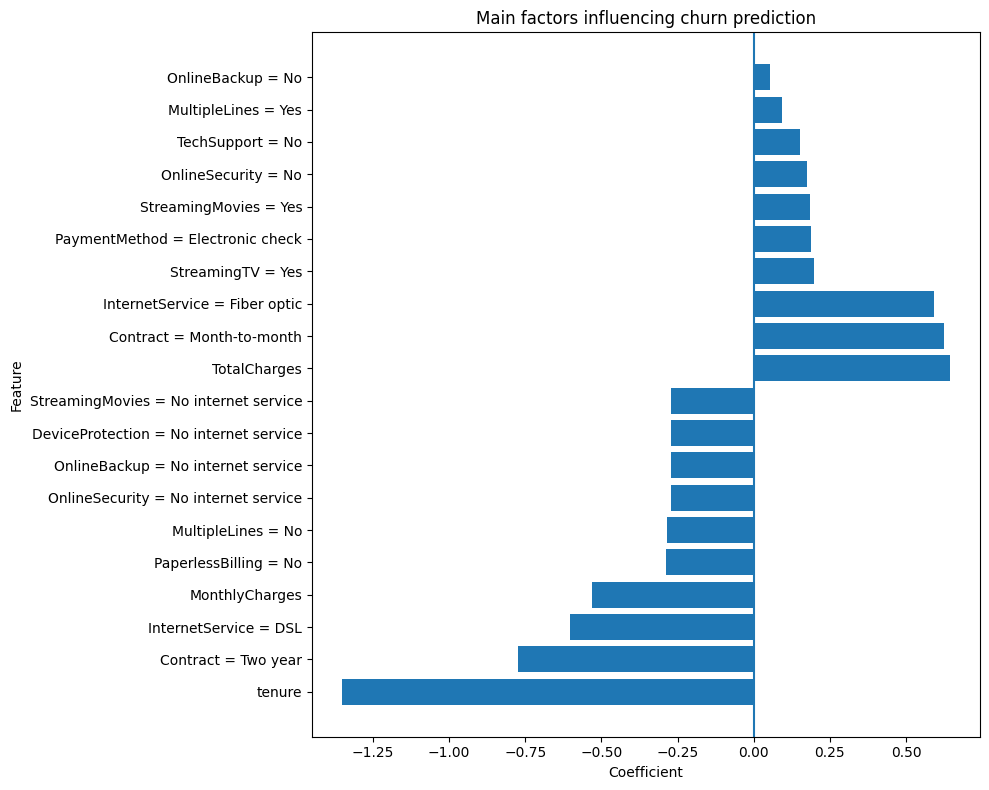

In [22]:
top_features_clean = pd.concat([top_negative_clean, top_positive_clean])

plt.figure(figsize=(10, 8))
plt.barh(top_features_clean["feature_clean"], top_features_clean["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Main factors influencing churn prediction")
plt.axvline(x=0)
plt.tight_layout()
plt.show()

## 14. Saving the final model

We export the selected pipeline and decision threshold for the Streamlit application.

In [23]:
joblib.dump(logreg_pipeline, "../models/churn_pipeline.joblib")
print("Pipeline saved to ../models/churn_pipeline.joblib")

Pipeline saved to ../models/churn_pipeline.joblib


In [24]:
joblib.dump(best_threshold, "../models/best_threshold.joblib")
print("Threshold saved to ../models/best_threshold.joblib")

Threshold saved to ../models/best_threshold.joblib
